In [1]:
import pandas as pd

In [2]:
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Online Sales Data.csv')

In [5]:
df.columns

Index(['Transaction ID', 'Date', 'Product Category', 'Product Name',
       'Units Sold', 'Unit Price', 'Total Revenue', 'Region',
       'Payment Method'],
      dtype='object')

In [6]:
df.shape

(240, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


In [8]:
df.isnull().sum()

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df.columns = df.columns.str.replace(' ', '_')

In [11]:
df.columns

Index(['Transaction_ID', 'Date', 'Product_Category', 'Product_Name',
       'Units_Sold', 'Unit_Price', 'Total_Revenue', 'Region',
       'Payment_Method'],
      dtype='object')

In [12]:
df.drop_duplicates()

,Transaction_ID,Date,Product_Category,Product_Name,Units_Sold,Unit_Price,Total_Revenue,Region,Payment_Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal
...,...,...,...,...,...,...,...,...,...
235,10236,2024-08-23,Home Appliances,Nespresso Vertuo Next Coffee and Espresso Maker,1,159.99,159.99,Europe,PayPal
236,10237,2024-08-24,Clothing,Nike Air Force 1 Sneakers,3,90.00,270.00,Asia,Debit Card
237,10238,2024-08-25,Books,The Handmaid's Tale by Margaret Atwood,3,10.99,32.97,North America,Credit Card
238,10239,2024-08-26,Beauty Products,Sunday Riley Luna Sleeping Night Oil,1,55.00,55.00,Europe,PayPal


In [13]:
df['Total_Revenue'].sum()

np.float64(80567.84999999999)

In [14]:
df.columns

Index(['Transaction_ID', 'Date', 'Product_Category', 'Product_Name',
       'Units_Sold', 'Unit_Price', 'Total_Revenue', 'Region',
       'Payment_Method'],
      dtype='object')

In [15]:
Revenue_by_category= df.groupby('Product_Category')['Total_Revenue'].sum().sort_values(ascending=False)

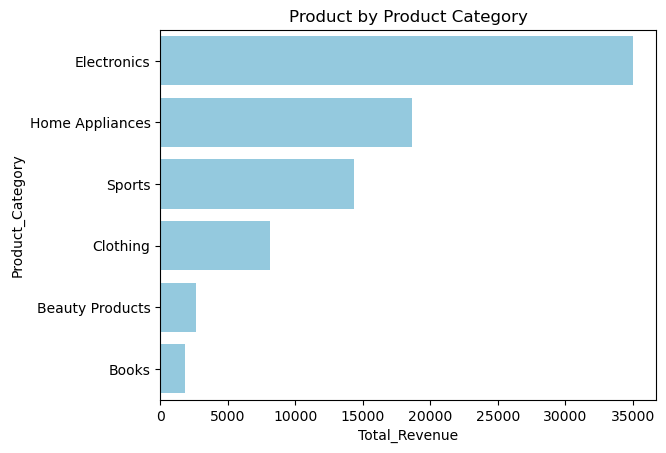

In [16]:
sns.barplot(x=Revenue_by_category, y=Revenue_by_category.index, color='skyblue')
plt.title("Product by Product Category")
plt.show()

In [17]:
top_5_product = df.groupby('Product_Name')['Total_Revenue'].sum().sort_values(ascending=False).head(5)

In [18]:
print(top_5_product)

Product_Name
Canon EOS R5 Camera          3899.99
LG OLED TV                   2599.98
MacBook Pro 16-inch          2499.99
Apple MacBook Pro 16-inch    2399.00
iPhone 14 Pro                1999.98
Name: Total_Revenue, dtype: float64


In [19]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

In [20]:
monthly_sales = df.groupby('Month')['Total_Revenue'].sum()

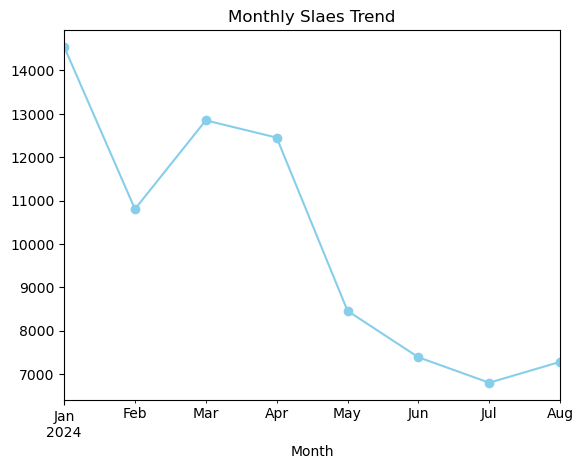

In [21]:
monthly_sales.plot(kind = 'line', marker='o', color='skyblue')
plt.title("Monthly Slaes Trend")
plt.show()

In [22]:
peak_month = monthly_sales.sort_values(ascending=False).head(1)

In [23]:
print(peak_month)

Month
2024-01    14548.32
Freq: M, Name: Total_Revenue, dtype: float64


In [24]:
df.groupby('Region')['Total_Revenue'].sum().sort_values(ascending=False)


Region
North America    36844.34
Asia             22455.45
Europe           21268.06
Name: Total_Revenue, dtype: float64

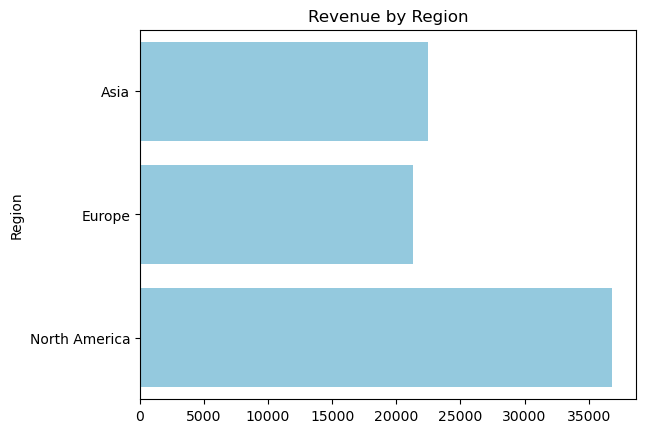

In [25]:
Revenue_by_Region = df.groupby('Region')['Total_Revenue'].sum()
sns.barplot(x=Revenue_by_Region.values, y=Revenue_by_Region.index, color='skyblue')
plt.title("Revenue by Region")
plt.show()

In [26]:
df['Payment_Method'].value_counts()

Payment_Method
Credit Card    120
PayPal          80
Debit Card      40
Name: count, dtype: int64

In [27]:
df.groupby('Payment_Method')['Total_Revenue'].sum()

Payment_Method
Credit Card    51170.86
Debit Card      8128.93
PayPal         21268.06
Name: Total_Revenue, dtype: float64

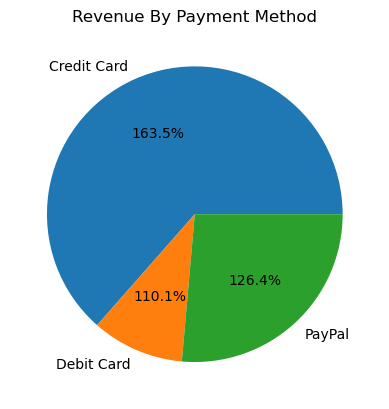

In [28]:
Revenue_payment_method = df.groupby('Payment_Method')['Total_Revenue'].sum().plot(kind='pie',autopct='1%.1f%%', color='red')
plt.ylabel("")
plt.title("Revenue By Payment Method")
plt.show()

In [29]:
top_products = df.groupby('Product_Name')['Total_Revenue'].sum().sort_values(ascending=False)

In [30]:
top_10_percent = int(len(top_products) * 0.1)

In [31]:
top_10_revenue = top_products.head(top_10_percent).sum()

In [32]:
total_revenue = top_products.sum()

In [34]:
top_10_revenue / total_revenue * 100

np.float64(45.481702689099926)